# Regresión lineal

En este notebook trabajaremos con datos simulados para estudiar:

- cómo se ajusta una regresión lineal
- cómo se evalúa un modelo de regresión
- cómo cambia el ajuste frente a outliers
- cómo funciona Gradient Descent
- cómo Ridge, Lasso y Elastic Net modifican los coeficientes.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)



## Instrucciones

Este notebook combina celdas demostrativas con preguntas de análisis.

No basta con ejecutar el código: deben interpretar los resultados, comparar métricas y justificar sus respuestas usando gráficos, coeficientes y residuos.

In [5]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.model_selection import KFold
from sklearn import linear_model # Nuevo modelo desbloqueado

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
#matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

In [6]:
from sklearn.metrics._scorer import _SCORERS

#### Generamos un dataset de juguete

Primero trabajaremos con datos simulados. La ventaja es que conocemos la relación verdadera:
$$
y_{\rm true} = 3x + 3
$$

Luego agregamos ruido para simular mediciones imperfectas.

In [8]:
np.random.seed(16) #fijar semilla para la reproducibilidad

x = np.arange(100) 

yp = 3*x + 3 + 2*(np.random.poisson(3*x+3,100)-(3*x+3)) 
#genera datos con dispersión, siguiendo una distribución Poissoniana
# con valor esperado = y (modelo lineal), centrado alrededor de cero

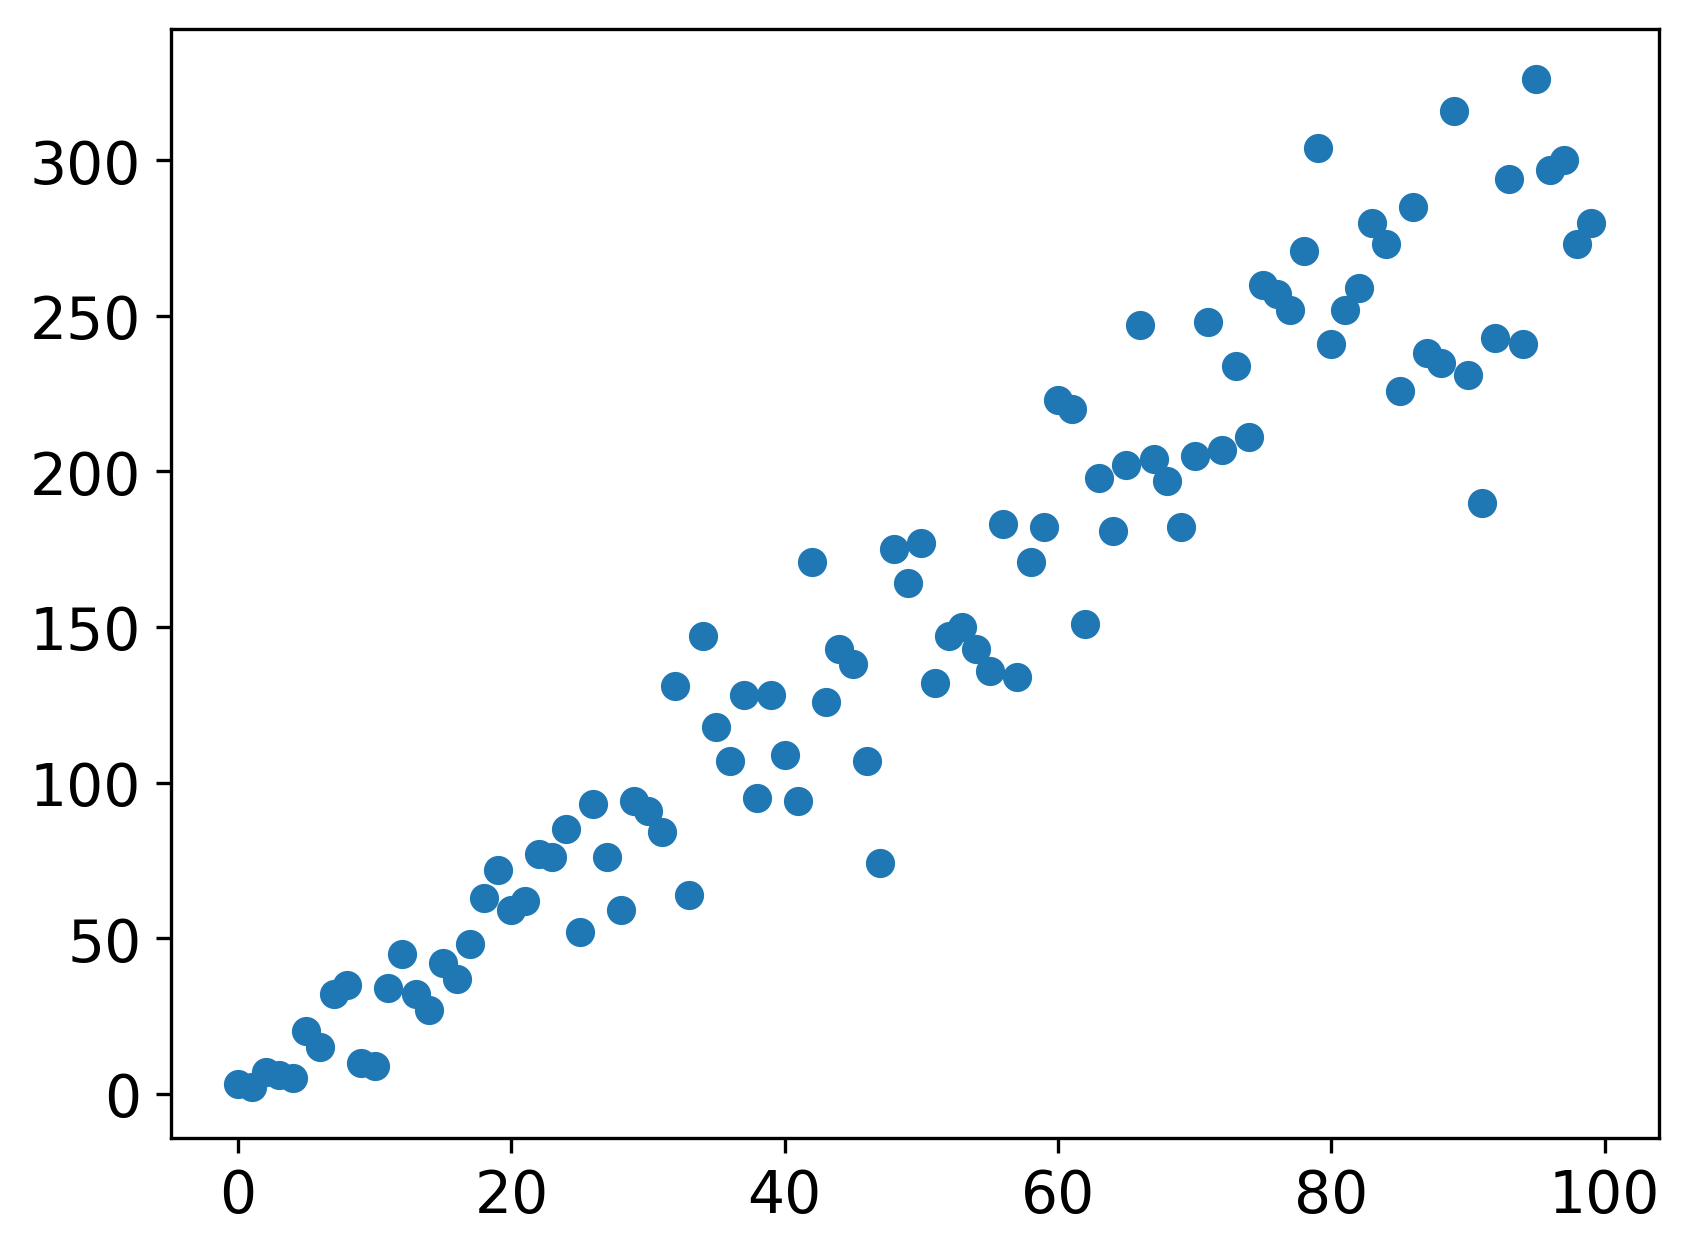

In [9]:
plt.scatter(x, yp);

### Pregunta 

De acuerdo al gráfico anterior:
- ¿Los datos siguen una tendencia aproximadamente lineal?
- ¿La dispersión alrededor de la recta parece constante para todos los valores de \(x\)?
- ¿Qué podría implicar esto al mirar residuos más adelante?

1. si
2. no, parece ser mayor la dispersion a medida que aumenta x
3. no todos los residuos van a ser iguales

In [12]:
model = linear_model.LinearRegression()

#### Ajuste con regresión lineal

Ajustaremos un modelo de la forma:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

En `sklearn`, cuando tenemos una sola feature, necesitamos escribir `x` como una matriz de forma `(n_samples, 1)`. Por eso usamos:

```python
x.reshape(-1, 1)

In [14]:
model.fit(x.reshape(-1, 1), yp)

LinearRegression()

In [15]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Intercepto beta_0 = {intercept:.3f}")
print(f"Pendiente beta_1 = {slope:.3f}")

Intercepto beta_0 = -0.126
Pendiente beta_1 = 3.025


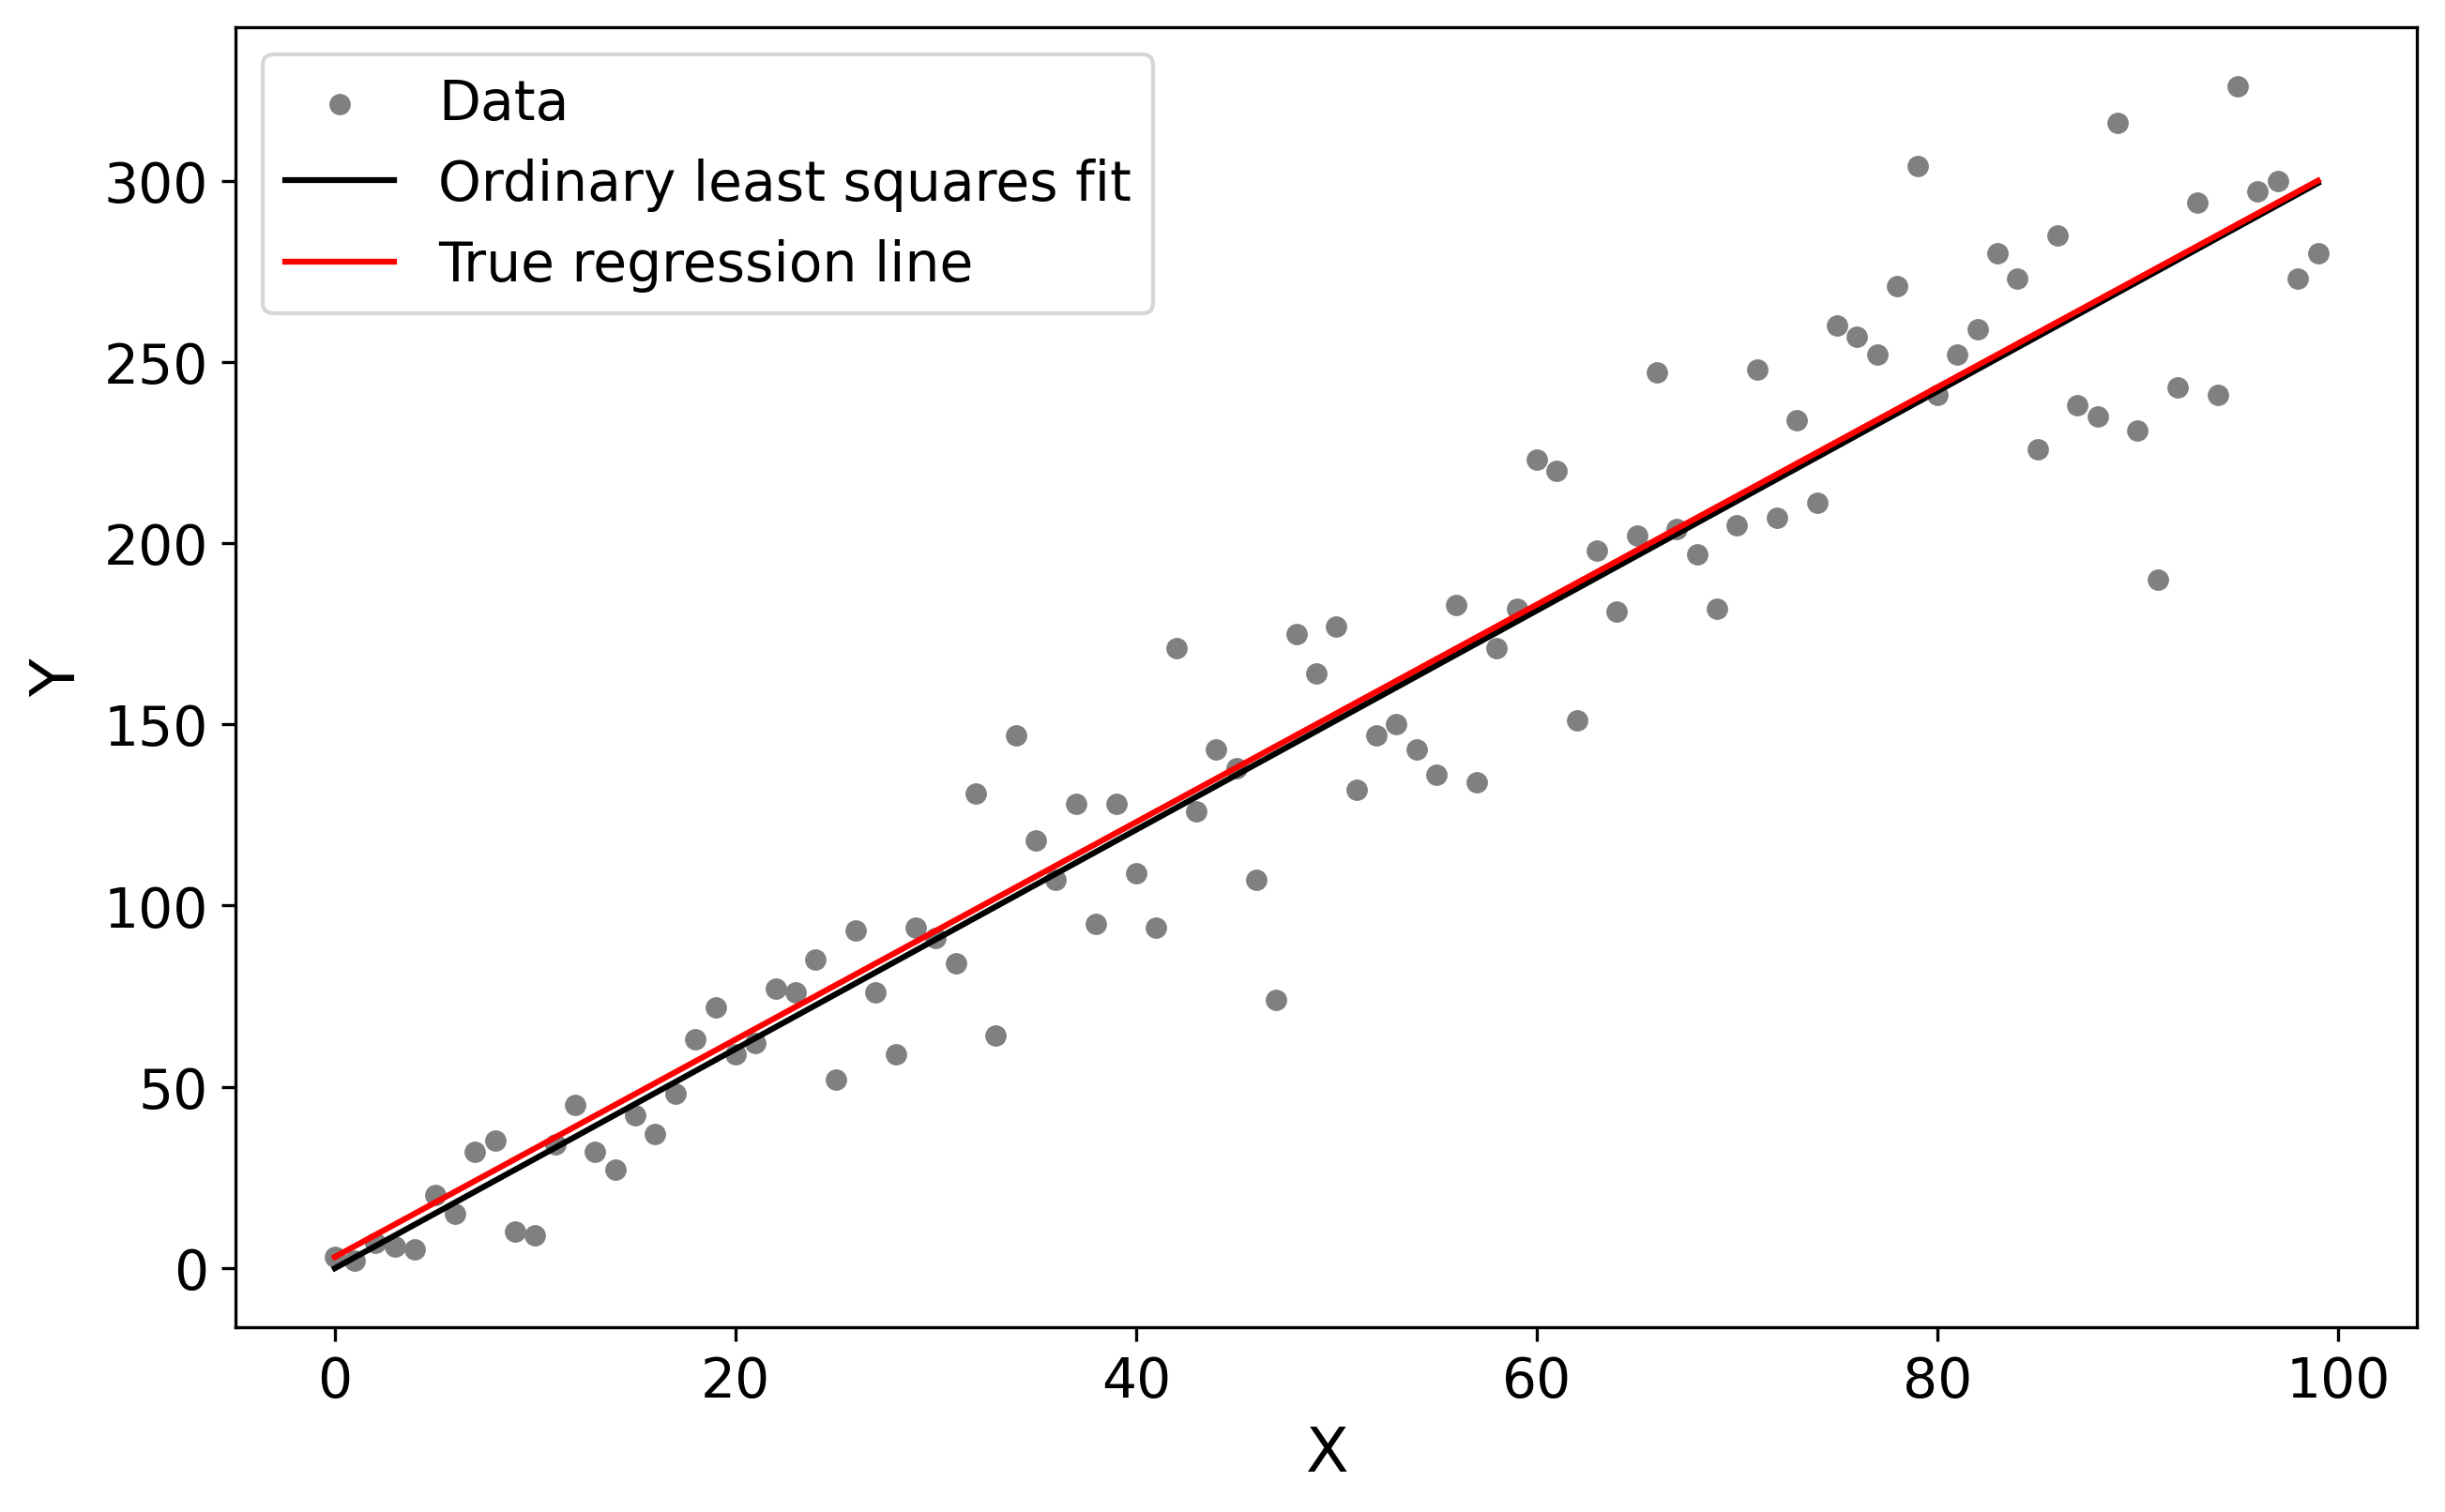

In [16]:
plt.figure(figsize = (10,6))
plt.scatter(x,yp, s = 20, c = 'gray', label = 'Data')
plt.plot(x, slope*x + intercept, c ='k', label = 'Ordinary least squares fit')
plt.plot(x, 3*x + 3, c = 'r', label = 'True regression line')
plt.legend(fontsize = 14)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### Pregunta

Compara los coeficientes ajustados con los valores verdaderos $\beta_0=3$ y $\beta_1=3$
-  ¿Son exactamente iguales? ¿Por qué?
-  ¿Qué representa físicamente/matemáticamente la pendiente en este modelo?

1. no lo son
2. la razon de cambio entre x e y

#### Solución analítica de mínimos cuadrados

Para regresión lineal simple, la pendiente que minimiza el MSE puede escribirse como:

$$
\beta_1 =
\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}
{\sum_i (x_i-\bar{x})^2}
$$

y luego:

$$
\beta_0 = \bar{y} - \beta_1\bar{x}
$$

**Implemente en el código para calcular a partir de la solución analítica los coeficientes y compare**

In [20]:
n=0
x_p=(sum(x)/len(x))
y_p=sum(yp)/len(yp)
num=0
den=0
while n < 100:
    num+=(x[n]-x_p)*(yp[n]-y_p)
    den+=(x[n]-x_p)**2
    n+=1

beta1=num/den

beta0=sum(yp)/len(yp)-beta1*(sum(x)/len(x))

print(f"Beta_0 analítico = {beta0:.3f}")
print(f"Beta_1 analítico = {beta1:.3f}")

Beta_0 analítico = -0.126
Beta_1 analítico = 3.025


#### Evaluación del modelo: validación cruzada y métricas

Ahora aplicamos una idea que ya usamos en clasificación: validar el modelo en distintos subconjuntos de datos.

Por defecto, `LinearRegression.score()` devuelve \(R^2\), no accuracy.

Podemos ver todos los scorers implementados en sklearn

In [23]:
from sklearn.metrics import get_scorer_names
print(get_scorer_names())

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'max_error', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples', 'r

#### Implemente una validación cruzada con Kfold

y encuentre los resultados para las métricas R^2, 'neg_mean_absolute_error'  (MAE) y 'neg_mean_squared_error' (MSE)

Para los estimadores de la performance del modelo del tipo "error" siempre queremos que sean pequeños (menor error, mejor modelo). Pero en sklearn, reciben un signo negativo, como neg_mean_squared_error, para mantener la consistencia de "alto puntaje=mejor" de los scorers

In [25]:
kf=KFold(shuffle=True, n_splits=10, random_state=10)

In [26]:
scores_r2 = cross_validate(model, x.reshape(-1,1), yp, cv=kf, scoring="r2", return_train_score=True)#implemente una validacion cruzada
print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

R2 test : 0.898 ± 0.073
R2 train: 0.925 ± 0.006


In [27]:
scores_mse = cross_validate(model, x.reshape(-1,1), yp, cv=kf, scoring="neg_mean_squared_error")#implemente una validacion cruzada

scores_mae = cross_validate(model, x.reshape(-1,1), yp, cv=kf, scoring="neg_mean_absolute_error")#implemente una validacion cruzada

print(f"MSE test: {-scores_mse['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f}")

MSE test: 655.479
MAE test: 19.361


**Haga un gráfico de los residuos $r_i=y_i-\hat{y}_i$**

In [31]:
r=[]
n=0
while n < 100:
    r.append(yp[n]-(slope*x[n]+intercept))
    n+=1

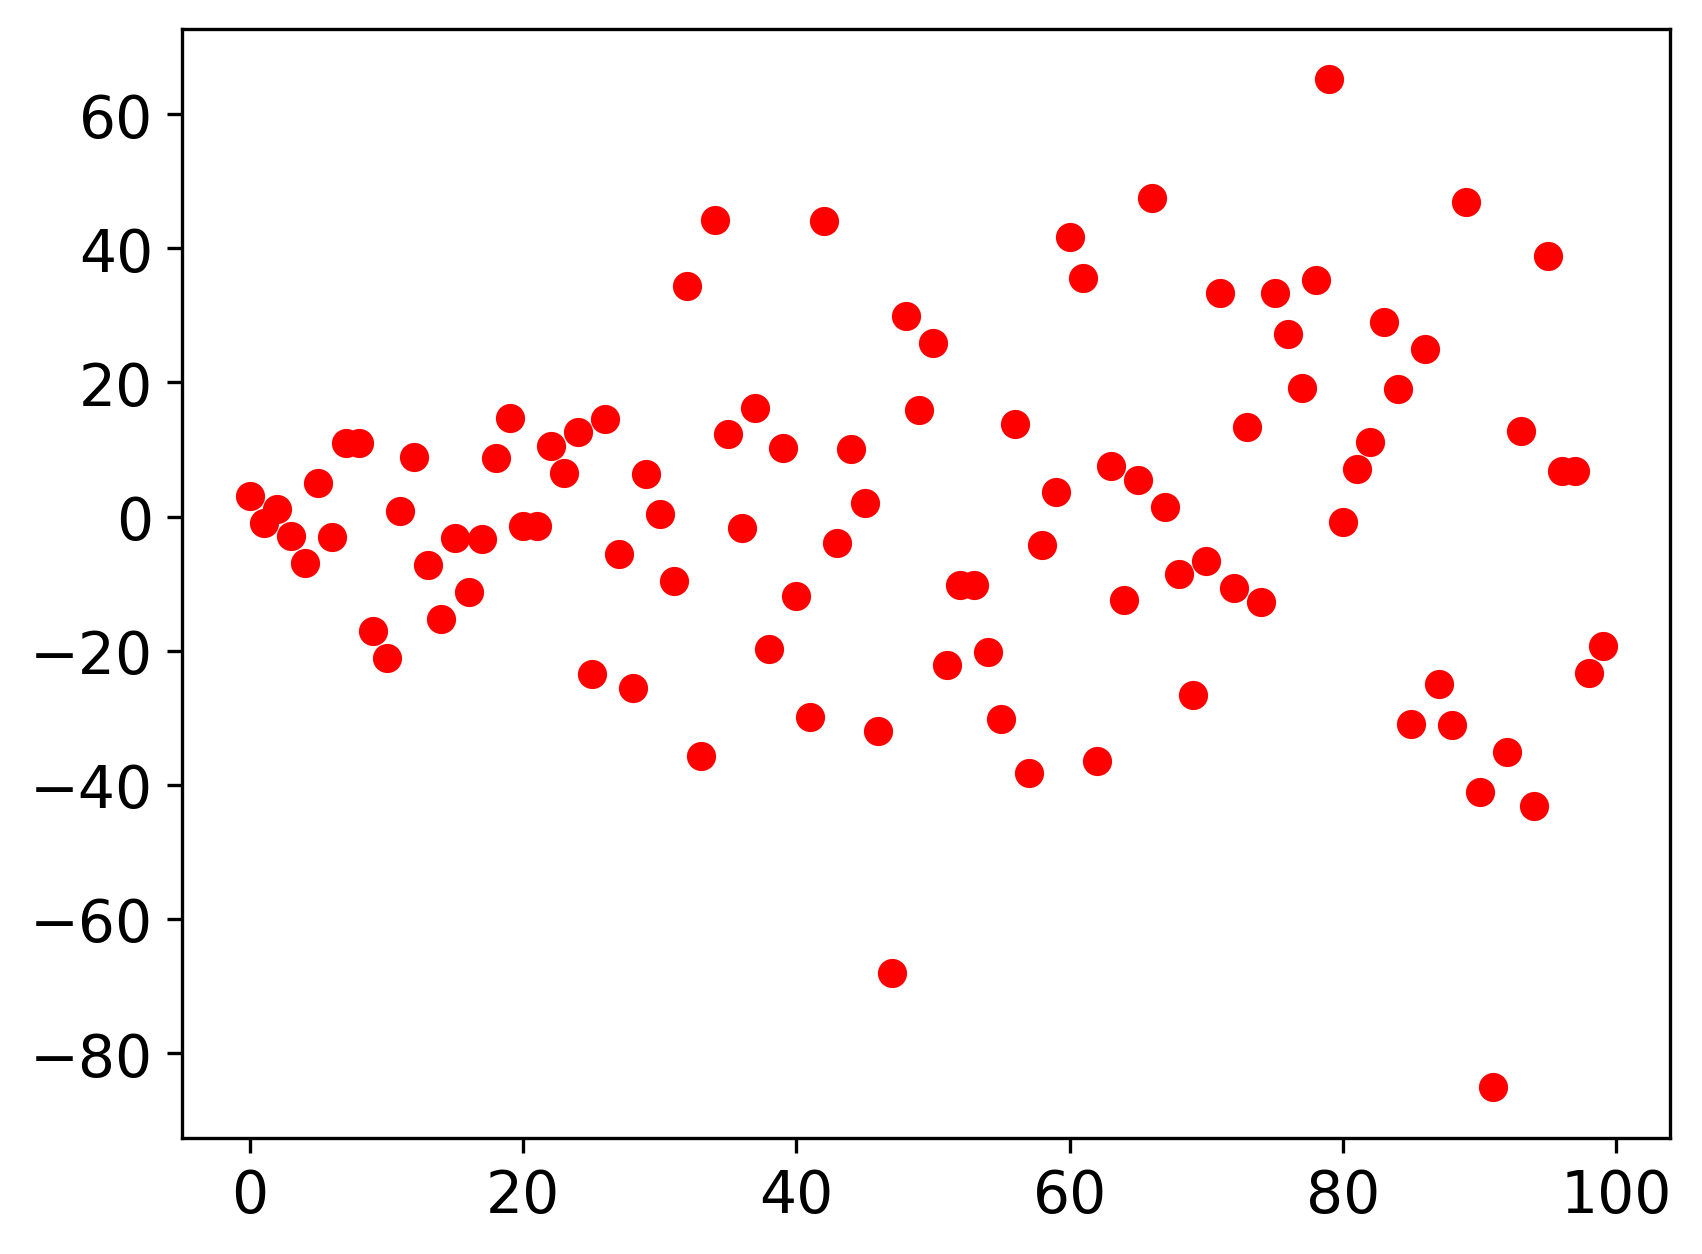

In [32]:
plt.plot(x,r,"ro")

#### Pregunta 
-  ¿Los residuos parecen distribuidos aleatoriamente alrededor de cero?
-  ¿La dispersión de los residuos cambia con $x$?
-  ¿Qué nos dice esto sobre el modelo y/o sobre cómo fueron generados los datos?

1. no del todo
2. aumenta la dispercion a medida que se aleja de 0
3. a medida que se avanza en x los datos reales tienden a alejarse del modelo

### ¿Qué ocurre si agregamos outliers?

In [36]:
np.random.seed(12) # fijada la semilla
out = np.random.choice(100,15) #seleccionamos 15 índices de outliers
yp_wo = np.copy(yp)
np.random.seed(12) #fijada 
yp_wo[out] = yp_wo[out] + 5*np.random.rand(15)*yp[out]

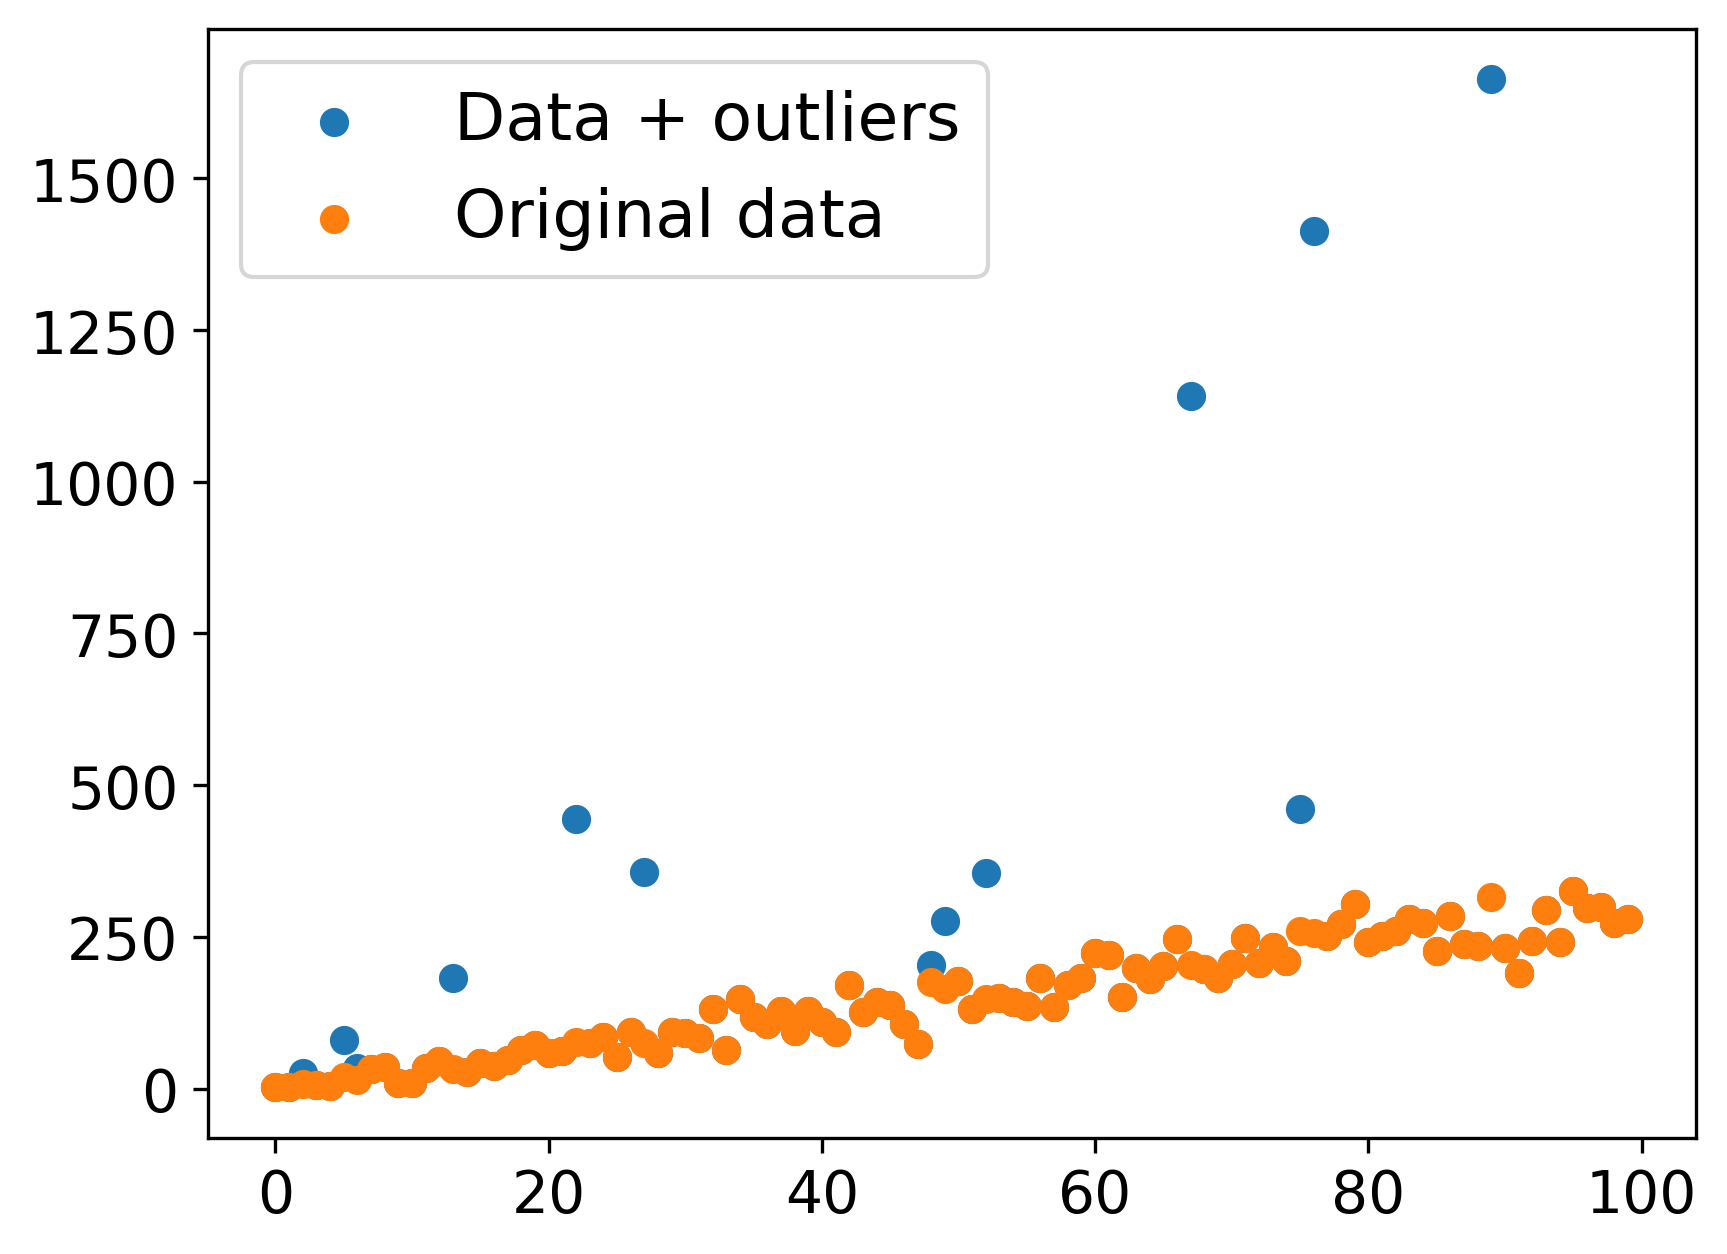

In [37]:
plt.scatter(x,yp_wo, label = 'Data + outliers')
plt.scatter(x,yp, label = 'Original data')
plt.legend();

#### Ajuste el modelo de regresión lineal para los datos con outliers

Responda: 
- Compare visualmente el ajuste antes y después de agregar outliers. ¿La recta cambia mucho? ¿Hacia dónde se mueve?
- Compara los coeficientes $\beta_0$ y $\beta_1$ del modelo con y sin outliers.  ¿Cuál cambia más: el intercepto o la pendiente?
- Compara las métricas MAE, MSE, RMSE y $R^2$ antes y después de agregar outliers. ¿Qué métrica se ve más afectada?
- ¿Por qué el MSE/RMSE suele ser más sensible a outliers que el MAE?
- ¿Todos los outliers afectan de la misma manera al modelo? Observa si los puntos atípicos están lejos en $y$, lejos en $x$, o en ambos.
- ¿Dirías que el modelo con outliers está aprendiendo la tendencia general de los datos o está siendo “tirado” por algunos puntos extremos? Justifica.
- Si este fuera un dataset real, ¿eliminarías los outliers automáticamente? Explica qué revisarías antes de decidir.

1. no cambia mucho, se mueve hacia arriba
2. el intercepto
3. MSE se ve más afectada
4. porque MSE y RMSE tienen las distancias entre los puntos al cuadrado mientras que MAE solo tiene la distancia entre los puntos en valor absoluto
5. Los puntos atipicos estan muy lejos en el eje y los que estan más lejos afectan de peor manera al modelo
6. esta siedno "tirado" por los extremos ya que estos lo estan desviando de la tendencia de la mayoria de datos
7. dependiendo de la razon que los provocara los eliminaria o no, pero en general deberian de poder eliminarse

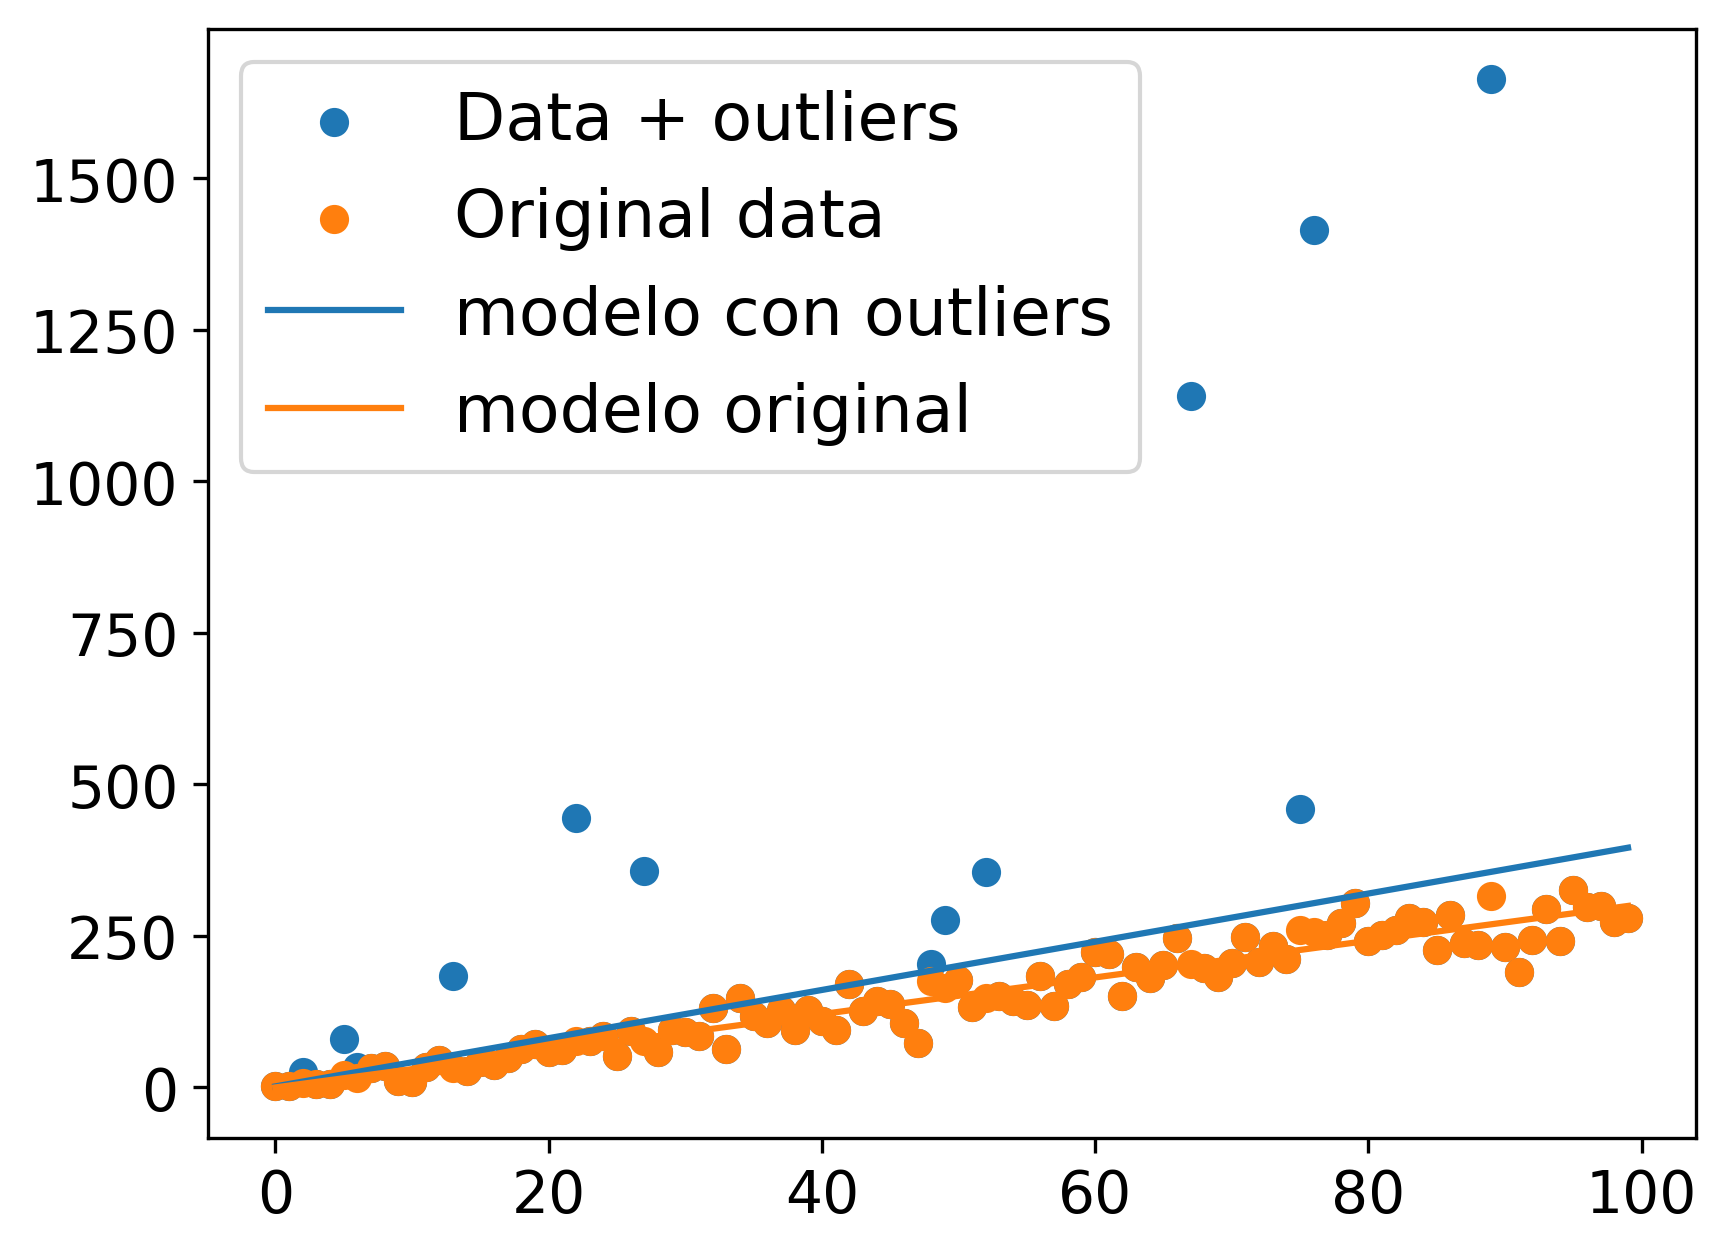

In [75]:
plt.scatter(x,yp_wo, label = 'Data + outliers')
plt.scatter(x,yp, label = 'Original data')
plt.plot(x,theta_ne[0]*x+theta_ne[1], label='modelo con outliers')
plt.plot(x,slope*x+intercept, label='modelo original')
plt.legend();

In [64]:
model_outliers=model.fit(x.reshape(-1,1),yp_wo) #implemente el modelo aca

Del resultado del modelo lineal para estos datos con outliers, guarde los coeficientes encontrados en un array llamado `theta_ne`

In [67]:
theta_ne = np.array([[model.coef_[0]],[model.intercept_]])
theta_ne

array([[3.97842184],
       [1.54811881]])

In [77]:
slope, intercept

(3.0247584758475856, -0.1255445544555016)

In [95]:
scores_r2 = cross_validate(model_outliers, x.reshape(-1,1), yp_wo, cv=kf, scoring="r2", return_train_score=True)
scores_mse = cross_validate(model_outliers, x.reshape(-1,1), yp_wo, cv=kf, scoring="neg_mean_squared_error")
scores_mae = cross_validate(model_outliers, x.reshape(-1,1), yp_wo, cv=kf, scoring="neg_mean_absolute_error")
scores_rmse = cross_validate(model_outliers, x.reshape(-1,1), yp_wo, cv=kf, scoring="neg_root_mean_squared_error")
print(f"MSE test: {-scores_mse['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f}")
print(f"RMSE test: {-scores_rmse['test_score'].mean():.3f}")
print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

MSE test: 45361.076
MAE test: 93.751
RMSE test: 166.986
R2 test : 0.186 ± 0.497
R2 train: 0.236 ± 0.014


In [97]:
scores_r2 = cross_validate(model, x.reshape(-1,1), yp, cv=kf, scoring="r2", return_train_score=True)
scores_mse = cross_validate(model, x.reshape(-1,1), yp, cv=kf, scoring="neg_mean_squared_error")
scores_mae = cross_validate(model, x.reshape(-1,1), yp, cv=kf, scoring="neg_mean_absolute_error")
scores_rmse = cross_validate(model, x.reshape(-1,1), yp, cv=kf, scoring="neg_root_mean_squared_error")
print(f"MSE test: {-scores_mse['test_score'].mean():.3f}")
print(f"MAE test: {-scores_mae['test_score'].mean():.3f}")
print(f"RMSE test: {-scores_rmse['test_score'].mean():.3f}")
print(f"R2 test : {scores_r2['test_score'].mean():.3f} ± {scores_r2['test_score'].std():.3f}")
print(f"R2 train: {scores_r2['train_score'].mean():.3f} ± {scores_r2['train_score'].std():.3f}")

MSE test: 655.479
MAE test: 19.361
RMSE test: 25.103
R2 test : 0.898 ± 0.073
R2 train: 0.925 ± 0.006


Esto es la solución usando el modelo y la **ecuación normal**

### Ahora implementaremos 3 métodos de gradient descent: batch, estocástico y mini-batch

En esta sección ajustamos una regresión lineal usando Gradient Descent en vez de usar directamente `LinearRegression`. Compararemos con los resultados encontrados en la regresión con outliers.




Agregaremos $x_0=1$ a cada instancia, este es el término de bias ($\beta_0$) y se usa para escribir la solución en la forma de multiplicación de matrices 

$y=X\cdot \theta$

donde $\theta$ es el vector de coeficientes que incluye el término $\beta_0$  (término de bias) y $\beta_1, \beta_2, \beta_3,..., \beta_n$

In [53]:
X = np.c_[np.ones((100, 1)), x]  

print(X.shape) #la forma es el número de instancias x número de parámetros


(100, 2)


Podemos calcular la pérdida asociada con la ecuación normal, usando la expresión 

$\text{MSE} = \frac{1}{m}\|X\cdot \theta - y \|^2$

In [54]:
loss_ne = np.mean((X.dot(theta_ne) - yp_wo.reshape(-1,1))**2)

### Batch GD

In [55]:
np.random.seed(10) 

eta = 0.0001 #learning step (valor pequeño asegura convergencia, aunque lenta)
n_iterations = 1000 #puede cambiar este valor!!
m = 100 #número de instancias

theta_path_bgd = [] #arreglo para guardar los valores de los parámetros en cada iteración

theta = np.random.randn(2,1) #inicializamos con valores aleatorios

for iteration in range(n_iterations):
    gradients = 2/m * X.T.dot(X.dot(theta) - yp_wo.reshape(-1,1)) #gradiente de la función de pérdida respecto a theta
    theta = theta - eta * gradients #actualiza los valores de theta, en cada cálculo del gradiente, en cada paso
    theta_path_bgd.append(theta) #

theta_path_bgd = np.array(theta_path_bgd) #guardamos esos valores (útil para una visualización)

theta_bgd = theta #resultado final

In [56]:
theta_bgd

array([[1.38909891],
       [3.98081931]])

In [57]:
loss_bgd = np.sum(1/m*(X.dot(theta_bgd) - yp_wo.reshape(-1,1))**2)

In [58]:
loss_bgd

43259.08804185896

In [59]:
(loss_ne-loss_bgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

30.310266853466768

###  GD estocástico

In [121]:
np.random.seed(10) #

theta = np.random.randn(2,1)  #inicializa los parámetros

eta = 0.000001 #learning step, valor más pequeño evita saltos muy grandes(0.000005)

n_iterations = 10000 #necesitamos más iteraciones en este caso

theta_path_sgd = []

for epoch in range(n_iterations):
    
        random_index = np.random.randint(m) #índice aleatorio
        
        x_one = X[random_index:random_index+1] #sólo se selecciona una instancia del conjunto de datos (m es la cantidad total)
        
        y_one = yp_wo[random_index:random_index+1] 
        
        gradients = 2 * x_one.T.dot(x_one.dot(theta) - y_one)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)                 

theta_path_sgd = np.array(theta_path_sgd)

theta_sgd = theta

In [122]:
theta_sgd

array([[1.37416279],
       [4.06497555]])

In [62]:
loss_sgd = np.sum(1/m*(X.dot(theta_sgd) - yp_wo.reshape(-1,1))**2)

In [63]:
loss_sgd

43385.08132655123

In [64]:
(loss_ne-loss_sgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

30.10729358736454

### Mini batch GD

In [65]:
# See also implementation notes here: https://sebastianraschka.com/faq/docs/sgd-methods.html

np.random.seed(10)

theta = np.random.randn(2,1) 

eta = 0.000005

n_iterations = 1000

theta_path_mgd = []

minibatch_size = 10 

for epoch in range(n_iterations):
    
    shuffled_indices = np.random.permutation(m) #se desordena el arreglo para seleccionar distintos mini-batches
    
    X_shuffled = X[shuffled_indices]
    
    y_shuffled = yp_wo.reshape(-1,1)[shuffled_indices]
    
    xi = X_shuffled[:minibatch_size] #subset aleatorio para calcular el gradiente
    
    yi = y_shuffled[:minibatch_size]
    
    gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi) #(calculo del gradiente)
    
    theta = theta - eta * gradients
    
    theta_path_mgd.append(theta) #(atualizacion de los parametros)

theta_path_mgd = np.array(theta_path_mgd)

theta_mgd = theta 

print(theta_mgd)

[[1.38191988]
 [4.25542902]]


In [66]:
theta_mgd

array([[1.38191988],
       [4.25542902]])

In [67]:
loss_mgd = np.sum(1/m*(X.dot(theta_mgd) - yp_wo.reshape(-1,1))**2)

In [68]:
loss_mgd

43506.50418469318

In [69]:
(loss_ne-loss_mgd)/loss_ne*100 #diferencia porcentual con la ecuación normal

29.911683208948485

#### Comparación de GD
Veamos el camino que siguió cada método de GD que implementamos. El color más oscuro indica pasos posteriores

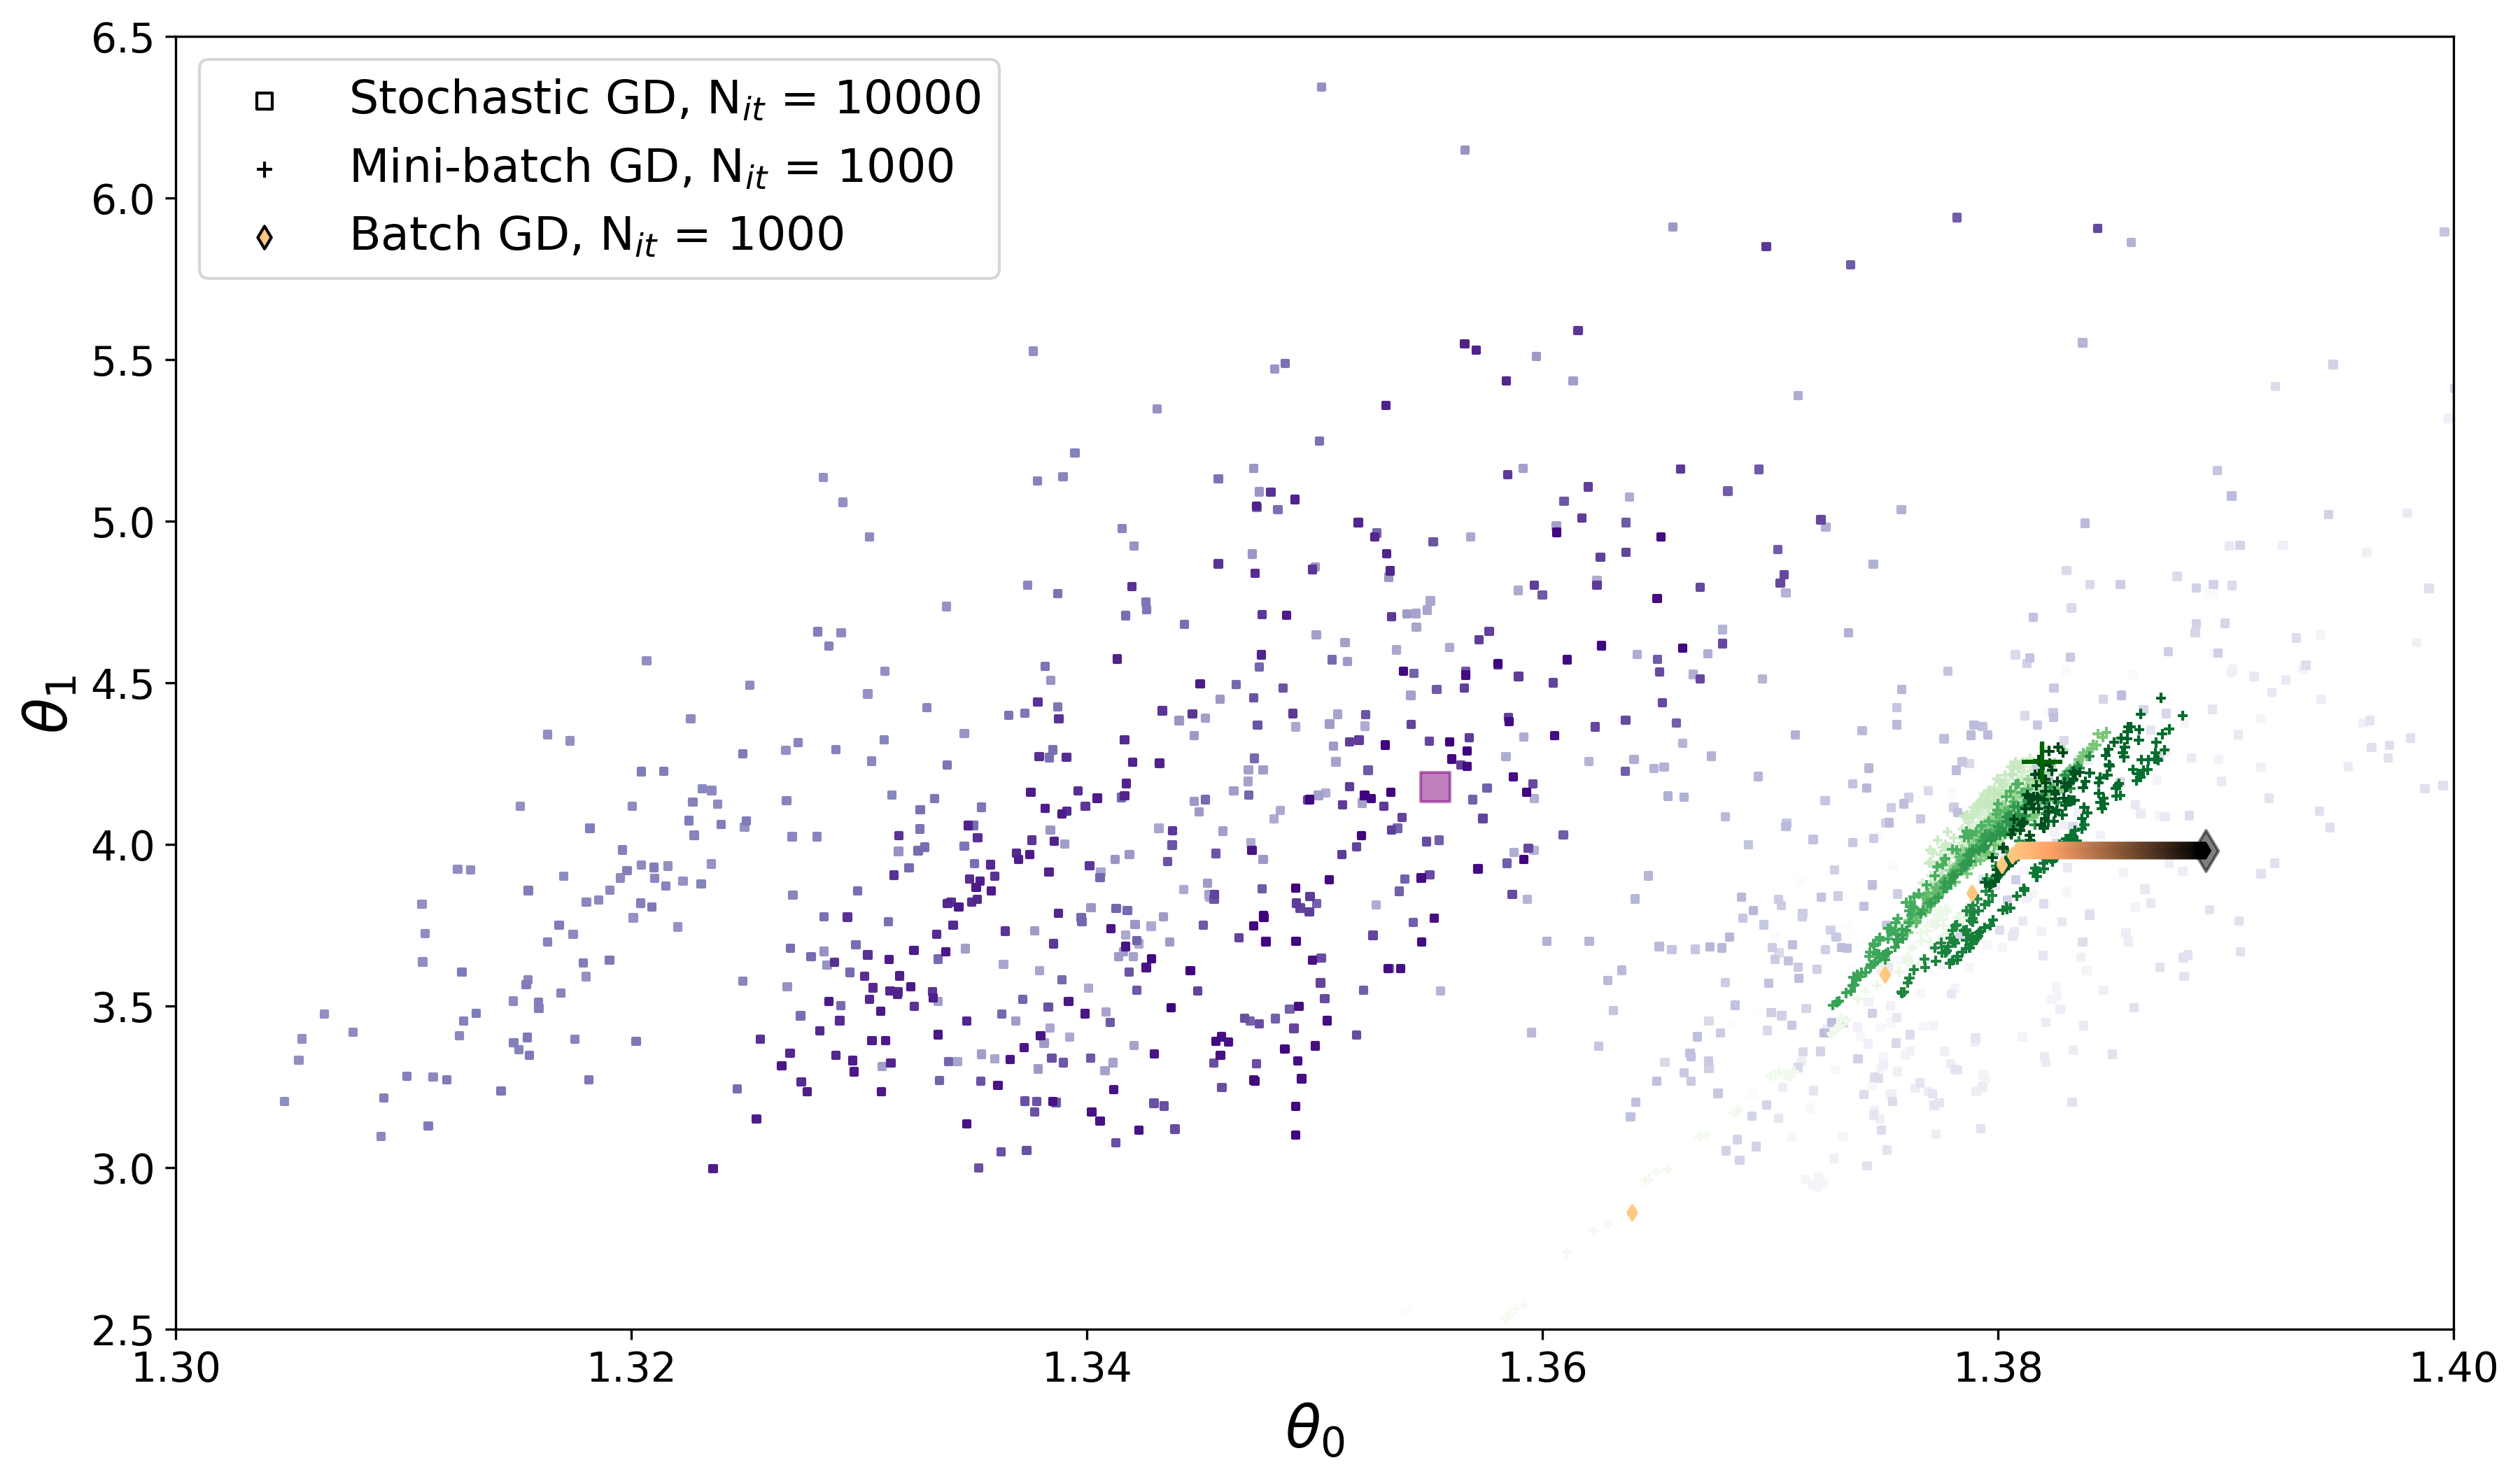

In [72]:
plt.figure(figsize=(14,8))

plt.scatter(theta_path_sgd[::10, 0].flatten(), theta_path_sgd[::10, 1].flatten(), marker = 's', s = 5, \
         label="Stochastic GD, N$_{it}$ = 10000", c = np.arange(1000), cmap=plt.cm.Purples)
plt.scatter(theta_path_mgd[:, 0].flatten(), theta_path_mgd[:, 1].flatten(), marker = "+", s = 12, linewidth=1, \
            label="Mini-batch GD, N$_{it}$ = 1000", c = np.arange(1000), cmap=plt.cm.Greens)
plt.scatter(theta_path_bgd[:, 0].flatten(), theta_path_bgd[:, 1].flatten(), marker = "d", s = 12, linewidth=1, \
            label="Batch GD, N$_{it}$ = 1000", c = np.arange(1000,0,-1), cmap=plt.cm.copper)

plt.scatter(theta_sgd[0],theta_sgd[1], marker = "s", s = 100, color = 'Purple', alpha = 0.5)
plt.scatter(theta_mgd[0],theta_mgd[1], marker = "+", s = 200, color = 'DarkGreen', alpha = 1)
plt.scatter(theta_bgd[0],theta_bgd[1], marker = "d", s = 100, color = 'k', alpha = 0.5)

legend = plt.legend(loc="upper left", fontsize=16)


for i in range(3):

    legend.legend_handles[i].set_color('k')
    legend.legend_handles[i]._sizes = [30]

plt.xlabel(r"$\theta_0$", fontsize=20)
plt.ylabel(r"$\theta_1$   ", fontsize=20)

plt.axis([1.3, 1.4, 2.5, 6.5])

#plt.savefig('AllThePaths.png', dpi = 300)
plt.show()


### Preguntas

1. Identifica en el código de mini batch GD dónde ocurre cada paso:

   - cálculo de las predicciones
   - cálculo del error o residuo
   - cálculo del gradiente
   - actualización de los parámetros

2. ¿Qué representan los parámetros $\theta_0$ y $\theta_1$ en este modelo?

3. Compara los parámetros encontrados por Gradient Descent con los obtenidos mediante `LinearRegression`. ¿Son iguales o parecidos? ¿Por qué no necesariamente coinciden exactamente?


4. Cambia el learning rate $\eta$. Prueba al menos tres valores: uno pequeño, uno razonable y uno demasiado grande. ¿Qué ocurre en cada caso?


5. Explica con tus palabras por qué la actualización tiene un signo menos: $\theta \leftarrow \theta - \eta \nabla L$

6. En la solución analítica derivamos e igualamos a cero. En Gradient Descent no resolvemos directamente la ecuación.  ¿Qué hacemos en cambio?

7. Compara Batch Gradient Descent, Stochastic Gradient Descent y Mini-batch Gradient Descent.

   - ¿Cuál usa todos los datos en cada actualización?
   - ¿Cuál actualiza los parámetros con más ruido?
   - ¿Cuál parece converger de forma más suave?

2. Intercepto y pendiente
3. Son parecidos, no coinciden ya que el gd es una aproximacion a los parametros optimos mientras que LinearRegression usa la solucion analitica
4. si es demasiado grande diverge y entre más pequeño convege más lentamente
5. Porque el gradiente apunta en la direccion de la mayor taza de cambio por lo que el signo menos hace que apunte en la direccion contaria apuntando hacia la menor taza de cambio asi aproximandose al lugar donde el gradiente se hace 0
6. utilizamos el gradiente para aproximarnos a donde el gradiente se hace 0
7. Batch Gradient Descent
8. stochastic Grdient Descent
9. Batch Gradient Descent